# Ekaterina's z-score baseline 

**Kaggel scores** 
- Channels 41-46: **0.454/0.810**
- All channels: 0.000/0.238

Reproduced `ek_baseline_zscore` with the three steps:
1. **FFT period detection** per channel → `freq_map.json` 
2. **Cascade decomposition** per channel → `sin1 + sin2 + sin3 + res`.
3. **Multi-window rolling z-score** → each frequency part normalised with a matching window.

Then: `top_p_mean` aggregation, grid search (`p × threshold`) on val with explicit percentile bounds.

## 1. Setup

In [73]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.ndimage import uniform_filter1d

from sentinel.ml_logic.metrics   import corrected_event_f05, compute_all_metrics
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.data      import find_anomaly_segments, load_target_channels, RAW_DIR
from sentinel.ml_logic.viz       import plot_timeline

sns.set_theme(style='whitegrid', context='notebook')
ANOMALY_COLOR = '#e74c3c'
NOMINAL_COLOR = '#2980b9'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [74]:
# ── Channel selection ────────────────────────────────────────────────────────
# Active: 6-channel subset (41–46).
BASE_CHANNELS = [f'channel_{i}' for i in range(41, 47)]

# Alternative: all 58 target channels — uncomment for broad variant.
# BASE_CHANNELS = load_target_channels()

# ── Decomposition config ─────────────────────────────────────────────────────
SUBCHANNEL_PARTS  = ['res', 'sin3']          # parts used as features (any subset of sin1/sin2/sin3/res)
BIG_WINDOW_DECOMP = 50_000                   # uniform_filter size for sin1 extraction
WINDOW_BY_PART    = {'sin1': 10_000, 'sin2': 10_000, 'sin3': 3_000, 'res': 300}

# ── Scoring hyperparameters ──────────────────────────────────────────────────
P_GRID  = [0.17, 0.33, 0.5, 0.67, 1.0]
N_SWEEP = 120
# Explicit tune_threshold bounds
LO_PCT  = (0, 90)
HI_PCT  = (1, 99.99)

# ── Split ────────────────────────────────────────────────────────────────────
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR      = RAW_DIR.parent        # <repo>/data
FREQ_MAP_PATH = DATA_DIR / 'freq_map.json'

# ── Identifiers for optional save/submit cells ───────────────────────────────
MODEL_NAME      = f'zscore_{len(BASE_CHANNELS)}ch_decomp_{"_".join(SUBCHANNEL_PARTS)}'
SUBMISSION_STEM = f'nb21_{MODEL_NAME}'

print(f'Base channels    : {len(BASE_CHANNELS)}  ({BASE_CHANNELS[0]} … {BASE_CHANNELS[-1]})')
print(f'Subchannel parts : {SUBCHANNEL_PARTS}   →  {len(BASE_CHANNELS)*len(SUBCHANNEL_PARTS)} features')
print(f'Big window       : {BIG_WINDOW_DECOMP:,}')
print(f'Window by part   : {WINDOW_BY_PART}')
print(f'P grid           : {P_GRID}')
print(f'Tune bounds      : lo={LO_PCT}  hi={HI_PCT}')
print(f'Tune metric      : corrected_event_f05  (ESA / Kaggle)')
print(f'Split            : {TRAIN_FRAC:.0%} / {VAL_FRAC:.0%} / {1-TRAIN_FRAC-VAL_FRAC:.0%}')
print(f'freq_map path    : {FREQ_MAP_PATH}  (exists: {FREQ_MAP_PATH.exists()})')
print(f'MODEL_NAME       : {MODEL_NAME}')

Base channels    : 6  (channel_41 … channel_46)
Subchannel parts : ['res', 'sin3']   →  12 features
Big window       : 50,000
Window by part   : {'sin1': 10000, 'sin2': 10000, 'sin3': 3000, 'res': 300}
P grid           : [0.17, 0.33, 0.5, 0.67, 1.0]
Tune bounds      : lo=(0, 90)  hi=(1, 99.99)
Tune metric      : corrected_event_f05  (ESA / Kaggle)
Split            : 70% / 15% / 15%
freq_map path    : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/freq_map.json  (exists: True)
MODEL_NAME       : zscore_6ch_decomp_res_sin3


## 2. Load raw parquets & temporal split

In [75]:
cols_train = ['id', 'is_anomaly'] + BASE_CHANNELS
cols_test  = ['id'] + BASE_CHANNELS

train = pq.read_table(str(RAW_DIR / 'train.parquet'), columns=cols_train).to_pandas().set_index('id')
test  = pq.read_table(str(RAW_DIR / 'test.parquet'),  columns=cols_test ).to_pandas().set_index('id')

n       = len(train)
tr_end  = int(n * TRAIN_FRAC)
val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

y_tr       = train['is_anomaly'].values[:tr_end]
y_val      = train['is_anomaly'].values[tr_end:val_end]
y_test_int = train['is_anomaly'].values[val_end:]

print(f'Train : {len(train):,} rows  |  Test : {len(test):,} rows')
print(f'Slices: train={tr_end:,}  val={val_end-tr_end:,}  test_int={n-val_end:,}')
print(f'Anom  : train={y_tr.mean():.4%}  val={y_val.mean():.4%}  test_int={y_test_int.mean():.4%}')

Train : 14,728,321 rows  |  Test : 521,280 rows
Slices: train=10,309,824  val=2,209,248  test_int=2,209,249
Anom  : train=10.5014%  val=10.1136%  test_int=10.7724%


## 3. FFT period detection

Per-channel FFT on *nominal* training rows to find `T_small` (~100 rows, `sin3`) and `T_medium` (~2000 rows, `sin2`). See `ek_freq_eda.ipynb` cell 6 for the original derivation. Cached to `data/freq_map.json` so re-runs reuse it.

In [76]:
DS_FACTOR  = 10
MAX_PERIOD = 3_000_000

def find_periods(series, n_peaks=2, min_period=50, max_period=None, ds_factor=10):
    """FFT on a downsampled series. Returns list of {period, power}."""
    x = series.values[::ds_factor].astype(np.float64)
    x -= x.mean()
    N     = len(x)
    freqs = np.fft.rfftfreq(N)
    power = np.abs(np.fft.rfft(x)) ** 2
    min_freq = 2.0 / N
    if max_period is not None:
        min_freq = max(min_freq, ds_factor / max_period)
    max_freq = 1.0 / (min_period / ds_factor)
    search   = np.where((freqs > min_freq) & (freqs <= max_freq), power, 0.0)
    found = []
    for _ in range(n_peaks):
        idx = int(np.argmax(search))
        if search[idx] == 0:
            break
        period_orig = int(round(ds_factor / freqs[idx]))
        found.append({'period': period_orig, 'power': float(power[idx])})
        w = max(3, idx // 8)
        search[max(0, idx - w): idx + w + 1] = 0.0
    return sorted(found, key=lambda d: d['period'])


# Load existing cache (may be partial) and fill in missing channels.
if FREQ_MAP_PATH.exists():
    freq_map = json.loads(FREQ_MAP_PATH.read_text())
    print(f'Loaded cached freq_map from {FREQ_MAP_PATH} ({len(freq_map)} entries)')
else:
    freq_map = {}
    print('No cached freq_map — starting from scratch.')

missing = [ch for ch in BASE_CHANNELS if ch not in freq_map]
if missing:
    print(f'Computing freq_map via FFT for {len(missing)} missing channel(s) …')
    nom = train[train['is_anomaly'] == 0]
    for ch in missing:
        raw_arr = nom[ch].values.astype(np.float64)
        p_small = find_periods(nom[ch], n_peaks=1, min_period=50,  max_period=500,    ds_factor=DS_FACTOR)
        detrended = raw_arr - uniform_filter1d(raw_arr, size=BIG_WINDOW_DECOMP, mode='nearest')
        p_med   = find_periods(pd.Series(detrended), n_peaks=1, min_period=500, max_period=10_000, ds_factor=DS_FACTOR)
        T1 = p_small[0]['period'] if p_small else 98
        T2 = p_med[0]['period']   if p_med   else 2000
        freq_map[ch] = [T1, T2]
        print(f'  {ch}: T_small={T1:>6,}  T_medium={T2:>6,}')
    FREQ_MAP_PATH.write_text(json.dumps(freq_map, indent=2))
    print(f'Saved freq_map → {FREQ_MAP_PATH}')

print(f'\nfreq_map now covers {len(freq_map)} channels.')
for ch in BASE_CHANNELS:
    T1, T2 = freq_map[ch]
    print(f'  {ch}: T_small={T1:>6,}  T_medium={T2:>6,}')


Loaded cached freq_map from /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/freq_map.json (58 entries)

freq_map now covers 58 channels.
  channel_41: T_small=    98  T_medium= 2,159
  channel_42: T_small=    98  T_medium= 2,161
  channel_43: T_small=    98  T_medium= 2,161
  channel_44: T_small=    98  T_medium= 2,159
  channel_45: T_small=    98  T_medium= 2,161
  channel_46: T_small=    98  T_medium= 2,161


## 4. Cascade decomposition

Adds `{ch}_sin1, _sin2, _sin3, _res` columns. Runs on both `train` and `test`.

In [77]:
def _decompose(arr, bw, mw, sw):
    """Three-level cascade decomposition → (sin1, sin2, sin3, residual).

    float32 throughout — spacecraft signal precision doesn't need float64,
    and float32 gives ~20% speed-up on SIMD + halves peak RAM.
    """
    a    = np.asarray(arr, dtype=np.float32)
    sin1 = uniform_filter1d(a,             size=bw, mode='nearest')
    r1   = a - sin1
    s2r  = uniform_filter1d(r1,            size=mw, mode='nearest')
    s3r  = uniform_filter1d(r1 - s2r,     size=sw, mode='nearest')
    sin2 = uniform_filter1d(r1 - s3r,     size=mw, mode='nearest')
    r2   = r1 - sin2
    sin3 = uniform_filter1d(r2,            size=sw, mode='nearest')
    res  = r2 - sin3
    return sin1, sin2, sin3, res

_part_keys = ['sin1', 'sin2', 'sin3', 'res']

for df, label in [(train, 'train'), (test, 'test')]:
    t0 = time.time()
    print(f'Decomposing {label} ({len(df):,} rows) …')
    for ch in BASE_CHANNELS:
        T1, T2 = freq_map[ch]
        mw = max(T1 * 2, T2 // 3)
        sw = max(3, T1 // 5)
        parts = _decompose(df[ch].values, BIG_WINDOW_DECOMP, mw, sw)
        for name, arr in zip(_part_keys, parts):
            if name in SUBCHANNEL_PARTS:
                df[f'{ch}_{name}'] = arr  # already float32 from _decompose
        del df[ch]          # free ~14.7 M × 4 B per channel (~3 GB total at 58 ch)
        print(f'  {ch}: T1={T1}  T2={T2}  sw={sw}  mw={mw}  bw={BIG_WINDOW_DECOMP:,}')
    print(f'  {label} done in {time.time()-t0:.1f}s')

CHANNELS = [f'{ch}_{p}' for ch in BASE_CHANNELS for p in SUBCHANNEL_PARTS]
print(f'\nActive feature channels ({len(CHANNELS)}): {CHANNELS}')


Decomposing train (14,728,321 rows) …
  channel_41: T1=98  T2=2159  sw=19  mw=719  bw=50,000
  channel_42: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_43: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_44: T1=98  T2=2159  sw=19  mw=719  bw=50,000
  channel_45: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_46: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  train done in 1.2s
Decomposing test (521,280 rows) …
  channel_41: T1=98  T2=2159  sw=19  mw=719  bw=50,000
  channel_42: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_43: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_44: T1=98  T2=2159  sw=19  mw=719  bw=50,000
  channel_45: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  channel_46: T1=98  T2=2161  sw=19  mw=720  bw=50,000
  test done in 0.0s

Active feature channels (12): ['channel_41_res', 'channel_41_sin3', 'channel_42_res', 'channel_42_sin3', 'channel_43_res', 'channel_43_sin3', 'channel_44_res', 'channel_44_sin3', 'channel_45_res', 'channel_45_sin3', 'channel_4

## 5. Multi-window rolling z-score + top-p aggregation

Verbatim from `ek_baseline_zscore` cells 8–9. Each channel's rolling window matches its frequency part via `WINDOW_BY_PART`.

In [78]:
def rolling_zscore_multiwindow(df, channels, window_by_part):
    """Centered rolling z-score per channel — vectorized via uniform_filter1d.

    ~15× faster than pandas `.rolling().std()` at ≥10 M rows:
        sd = sqrt(E[x²] - E[x]²)   with   E[·] = uniform_filter1d
    For batch scoring (non-streaming) the centered vs causal window is fine.
    If a strictly causal window is required later, pass origin=-(w//2) to
    uniform_filter1d.
    """
    out = np.empty((len(df), len(channels)), dtype=np.float32)
    for j, ch in enumerate(channels):
        part = ch.rsplit('_', 1)[-1]          # 'res' / 'sin3' / ...
        w    = int(window_by_part.get(part, 1000))
        x    = df[ch].values.astype(np.float32, copy=False)

        mu  = uniform_filter1d(x,        size=w, mode='nearest')
        mu2 = uniform_filter1d(x * x,    size=w, mode='nearest')
        var = np.maximum(mu2 - mu * mu, 0.0)
        sd  = np.sqrt(var, dtype=np.float32)
        np.maximum(sd, np.float32(1e-8), out=sd)
        out[:, j] = (x - mu) / sd

    return pd.DataFrame(out, columns=channels, index=df.index)


def top_p_mean(z_arr, p):
    """Mean of top-p fraction of channels by abs Z-score."""
    n_top = max(1, int(z_arr.shape[1] * p))
    z_abs = np.abs(z_arr)
    top   = np.partition(z_abs, -n_top, axis=1)[:, -n_top:]
    return top.mean(axis=1)


In [79]:
t0 = time.time()
print(f'Computing multi-window Z-score ({WINDOW_BY_PART}) on {len(train):,} train rows × {len(CHANNELS)} channels …')
z_full     = rolling_zscore_multiwindow(train[CHANNELS], CHANNELS, WINDOW_BY_PART)
z_tr       = z_full.iloc[:tr_end]
z_val      = z_full.iloc[tr_end:val_end]
z_test_int = z_full.iloc[val_end:]
print(f'Done in {time.time()-t0:.1f}s.')

Computing multi-window Z-score ({'sin1': 10000, 'sin2': 10000, 'sin3': 3000, 'res': 300}) on 14,728,321 train rows × 12 channels …
Done in 1.7s.


## 6. Grid search `p × threshold` on val

Uses explicit `lo_percentile=(0, 90), hi_percentile=(1, 99.99)` bounds, but tunes on `corrected_event_f05` 

In [80]:
print(f'{"p":>6}  {"ESA F0.5":>9}  {"threshold":>11}')
print('-' * 32)

best_score, best_p, best_thr, best_sweep = -1, None, None, None
for p in P_GRID:
    scores_val_p = top_p_mean(z_val.values, p=p)
    res = tune_threshold(
        scores         = scores_val_p,
        y_true         = y_val,
        metric_fn      = corrected_event_f05,
        lo_percentile  = LO_PCT,
        hi_percentile  = HI_PCT,
        n_sweep        = N_SWEEP,
    )
    print(f'{p:>6.2f}  {res["score"]:>9.4f}  {res["threshold"]:>11.4g}')
    if res['score'] > best_score:
        best_score, best_p, best_thr, best_sweep = res['score'], p, res['threshold'], res

THRESHOLD = best_thr
n_top     = max(1, int(len(CHANNELS) * best_p))
print(f'\nBest  p={best_p}  (top-{n_top} of {len(CHANNELS)} features)  threshold={THRESHOLD:.6f}  ESA F0.5={best_score:.4f}')

     p   ESA F0.5    threshold
--------------------------------
  0.17     0.6061         5.22
  0.33     0.6977        4.089
  0.50     0.7692        3.005
  0.67     0.7692        2.517
  1.00     0.7692        2.046

Best  p=0.5  (top-6 of 12 features)  threshold=3.005465  ESA F0.5=0.7692


## 7. Model & scoring details 

In [81]:
scores_val      = top_p_mean(z_val.values,      p=best_p)
scores_test_int = top_p_mean(z_test_int.values, p=best_p)

print(f'── {MODEL_NAME} — scoring details ─────────────────────────────')
print(f'  base channels    : {len(BASE_CHANNELS)}  ({BASE_CHANNELS[0]}…{BASE_CHANNELS[-1]})')
print(f'  subchannel parts : {SUBCHANNEL_PARTS}  →  {len(CHANNELS)} features')
print(f'  window by part   : {WINDOW_BY_PART}')
print(f'  top-p            : {best_p}  (top-{n_top} of {len(CHANNELS)})')
print(f'  threshold        : {THRESHOLD:.6f}  (val-tuned, metric=corrected_event_f05)')
print(f'  tune score (val) : {best_score:.4f}')
print()
def _ratio(a, b): return a / max(b, 1e-9)
print(f'── Score distributions ────────────────────────────────────────')
print(f'  val  — nom mean: {scores_val[y_val==0].mean():.5f}   anom mean: {scores_val[y_val==1].mean():.5f}   ratio: {_ratio(scores_val[y_val==1].mean(), scores_val[y_val==0].mean()):.2f}x')
print(f'  test — nom mean: {scores_test_int[y_test_int==0].mean():.5f}   anom mean: {scores_test_int[y_test_int==1].mean():.5f}   ratio: {_ratio(scores_test_int[y_test_int==1].mean(), scores_test_int[y_test_int==0].mean()):.2f}x')
print()
print(f'── Score ranges ───────────────────────────────────────────────')
print(f'  val  : [{scores_val.min():.4f}, {scores_val.max():.4f}]')
print(f'  test : [{scores_test_int.min():.4f}, {scores_test_int.max():.4f}]')

── zscore_6ch_decomp_res_sin3 — scoring details ─────────────────────────────
  base channels    : 6  (channel_41…channel_46)
  subchannel parts : ['res', 'sin3']  →  12 features
  window by part   : {'sin1': 10000, 'sin2': 10000, 'sin3': 3000, 'res': 300}
  top-p            : 0.5  (top-6 of 12)
  threshold        : 3.005465  (val-tuned, metric=corrected_event_f05)
  tune score (val) : 0.7692

── Score distributions ────────────────────────────────────────
  val  — nom mean: 1.24940   anom mean: 1.25096   ratio: 1.00x
  test — nom mean: 1.24913   anom mean: 1.25015   ratio: 1.00x

── Score ranges ───────────────────────────────────────────────
  val  : [0.3025, 16.5865]
  test : [0.2973, 16.5625]


## Metrics 

### Full metric panel, threshold

In [82]:
y_pred_val      = (scores_val      > THRESHOLD).astype(np.int8)
y_pred_test_int = (scores_test_int > THRESHOLD).astype(np.int8)

m_val  = compute_all_metrics(y_val,      y_pred_val)
m_test = compute_all_metrics(y_test_int, y_pred_test_int)

# Compact one-table panel: only the metrics that matter for this competition.
# Event F0.5 is the Kaggle headline → highlighted row.
rows = [
    ('Event F0.5 (Kaggle)',  f"{m_val['event_f05']:.4f}",       f"{m_test['event_f05']:.4f}"),
    ('Event precision',      f"{m_val['event_precision']:.4f}", f"{m_test['event_precision']:.4f}"),
    ('Event recall',         f"{m_val['event_recall']:.4f}",    f"{m_test['event_recall']:.4f}"),
    ('Events hit',           f"{int(m_val['tp_events'])}/{int(m_val['n_events'])} ({m_val['tp_events']/max(m_val['n_events'],1):.1%})",
                             f"{int(m_test['tp_events'])}/{int(m_test['n_events'])} ({m_test['tp_events']/max(m_test['n_events'],1):.1%})"),
    ('FP predicted events',  f"{int(m_val['fp_pred_events'])}", f"{int(m_test['fp_pred_events'])}"),
    ('Positive rate',        f"{y_pred_val.mean():.2%}",        f"{y_pred_test_int.mean():.2%}"),
]
df_metrics = pd.DataFrame(rows, columns=['Metric', 'Val', 'Test intern']).set_index('Metric')

def _highlight_headline(row):
    return ['background-color: #fff3bf; font-weight: bold' if row.name == 'Event F0.5 (Kaggle)' else ''
            for _ in row]

caption = f'{MODEL_NAME} @ threshold {THRESHOLD:.4f}'
df_metrics.style.apply(_highlight_headline, axis=1).set_caption(caption)


,Val,Test intern
Metric,,
Event F0.5 (Kaggle),0.7692,0.7738
Event precision,0.9231,0.9286
Event recall,0.4615,0.4643
Events hit,12/26 (46.2%),13/28 (46.4%)
FP predicted events,1,1
Positive rate,0.00%,0.00%


### Headline bar chart — val vs test_intern

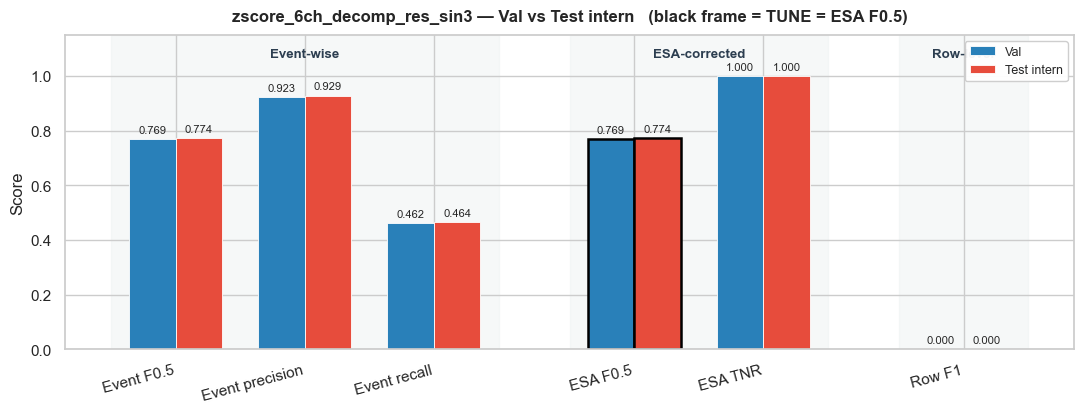

In [83]:
BAR_GROUPS = [
    ('Event-wise',    ['Event F0.5', 'Event precision', 'Event recall']),
    ('ESA-corrected', ['ESA F0.5', 'ESA TNR']),
    ('Row-level',     ['Row F1']),
]
LABEL_TO_KEY = {
    'Event F0.5'     : 'event_f05',
    'Event precision': 'event_precision',
    'Event recall'   : 'event_recall',
    'ESA F0.5'       : 'esa_f05',
    'ESA TNR'        : 'esa_tnr',
    'Row F1'         : 'row_f1',
}
TUNE_LABEL = 'ESA F0.5'

fig, ax = plt.subplots(figsize=(11, 4.3))
w, gap = 0.36, 0.55
xs, xticks, xlabels, band_edges = [], [], [], []
cursor = 0.0
for gname, labels in BAR_GROUPS:
    grp_start = cursor
    for lbl in labels:
        xs.append(cursor); xticks.append(cursor); xlabels.append(lbl)
        cursor += 1.0
    band_edges.append((gname, grp_start - 0.5, cursor - 0.5))
    cursor += gap

xs = np.asarray(xs)
vals_val  = [m_val [LABEL_TO_KEY[l]] for l in xlabels]
vals_test = [m_test[LABEL_TO_KEY[l]] for l in xlabels]
edges = ['black' if l == TUNE_LABEL else 'white' for l in xlabels]
lws   = [1.8   if l == TUNE_LABEL else 0.6     for l in xlabels]

b1 = ax.bar(xs - w/2, vals_val,  w, label='Val',         color=NOMINAL_COLOR, edgecolor=edges, linewidth=lws)
b2 = ax.bar(xs + w/2, vals_test, w, label='Test intern', color=ANOMALY_COLOR, edgecolor=edges, linewidth=lws)
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=3)

for gname, xlo, xhi in band_edges:
    ax.axvspan(xlo, xhi, color='#ecf0f1', alpha=0.45, zorder=0)
    ax.text((xlo + xhi)/2, 1.06, gname, ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#2c3e50')

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=15, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title(f'{MODEL_NAME} — Val vs Test intern   (black frame = TUNE = {TUNE_LABEL})', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
fig.tight_layout(); plt.show()

## Timeline 

In [84]:
from importlib import reload
from sentinel.ml_logic import viz
reload(viz)
from sentinel.ml_logic.viz import plot_timeline

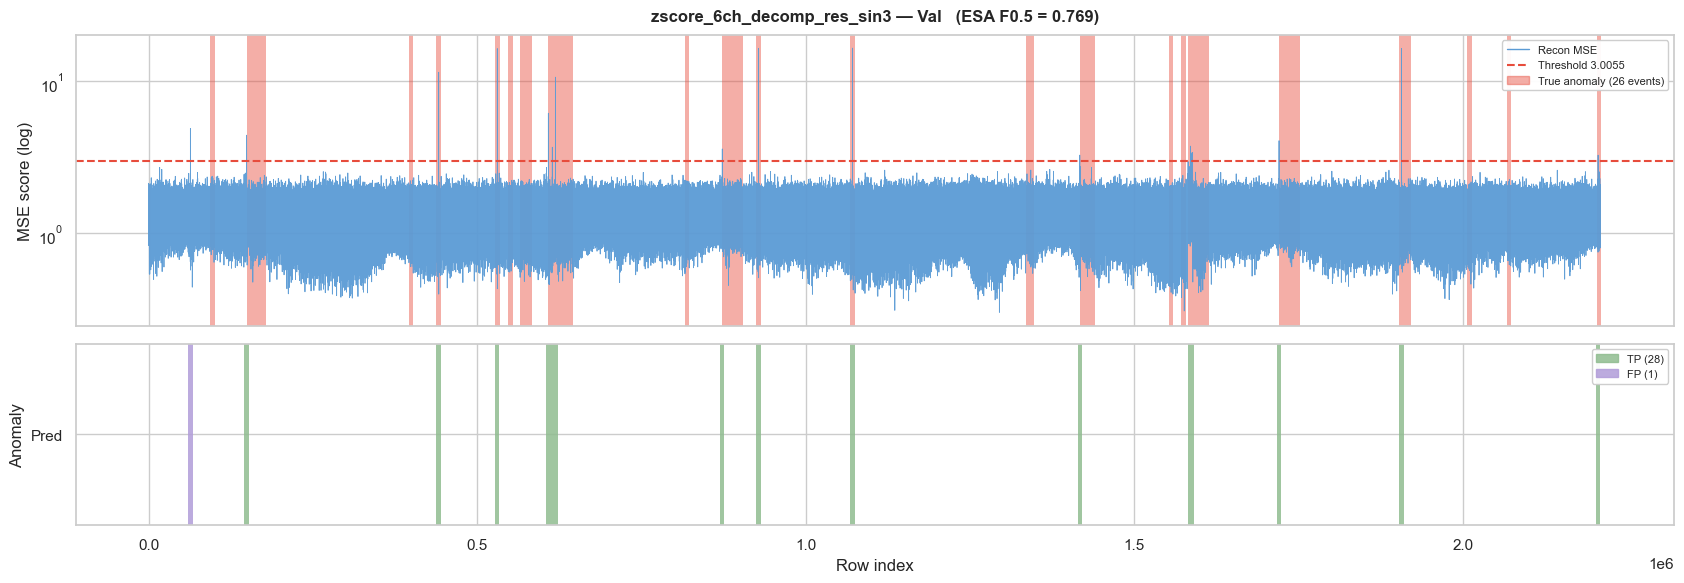

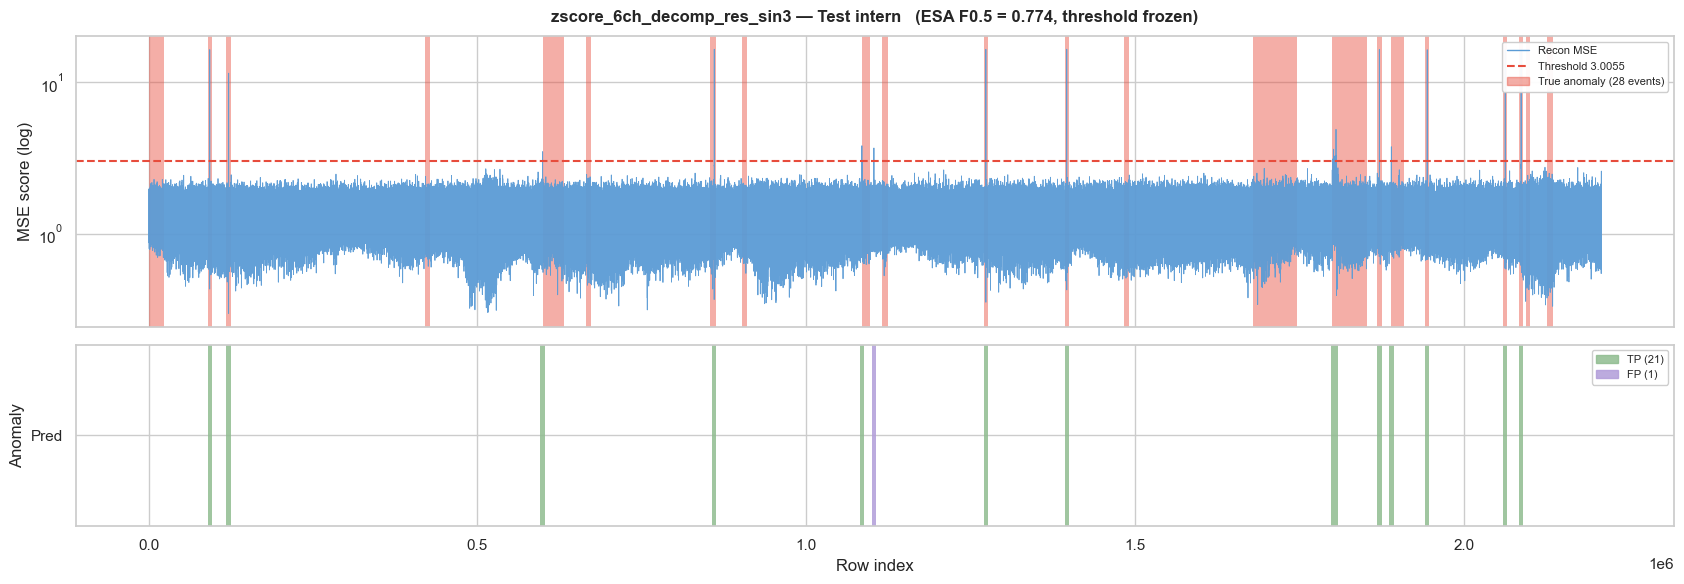

In [85]:
fig_val = plot_timeline(
    scores    = scores_val,
    y_true    = y_val,
    threshold = THRESHOLD,
    title     = f'{MODEL_NAME} — Val   (ESA F0.5 = {m_val["esa_f05"]:.3f})',
    ds=1,
    log_y     = True,
)
plt.show(); plt.close(fig_val)

fig_test = plot_timeline(
    scores    = scores_test_int,
    y_true    = y_test_int,
    threshold = THRESHOLD,
    title     = f'{MODEL_NAME} — Test intern   (ESA F0.5 = {m_test["esa_f05"]:.3f}, threshold frozen)',
    ds=1,
    log_y     = True,
)
plt.show(); plt.close(fig_test)

## Event analysis — detected vs missed, coverage, hit-rate

### Per-event table — detection status + hit rate

In [86]:
def event_table(scores, y_true, threshold, label):
    segments = find_anomaly_segments(y_true)
    y_pred   = (scores > threshold).astype(np.int8)
    rows = []
    for seg in segments:
        n_det = int(y_pred[seg['start']:seg['end']+1].sum())
        rows.append({
            'start'      : seg['start'],
            'end'        : seg['end'],
            'length'     : seg['length'],
            'detected'   : n_det > 0,
            'hit_rate'   : round(n_det / seg['length'], 3),
        })
    df = pd.DataFrame(rows)
    n_det  = int(df['detected'].sum()) if len(df) else 0
    n_miss = len(df) - n_det
    print(f'{label}: {n_det}/{len(df)} events detected  ({n_miss} missed)')
    return df

df_val  = event_table(scores_val,      y_val,      THRESHOLD, f'{MODEL_NAME} Val')
df_test = event_table(scores_test_int, y_test_int, THRESHOLD, f'{MODEL_NAME} Test intern')

zscore_6ch_decomp_res_sin3 Val: 12/26 events detected  (14 missed)
zscore_6ch_decomp_res_sin3 Test intern: 13/28 events detected  (15 missed)


### Plot events analysis

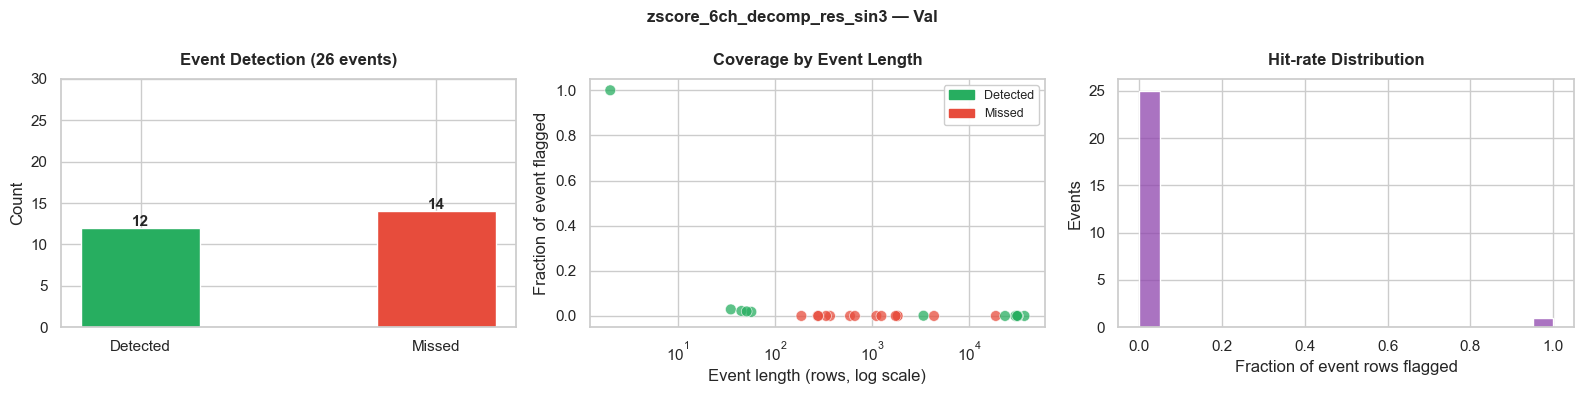

Missed events:
  start     end  length
  97133   97726     594
 399395  399763     369
 548497  552855    4359
 565099  584013   18915
 819541  819876     336
1337362 1339200    1839
1342475 1344310    1836
1556161 1556436     276
1573916 1575670    1755
1912322 1912508     187
1912819 1913928    1110
1917562 1918227     666
2009869 2010147     279
2069274 2070523    1250


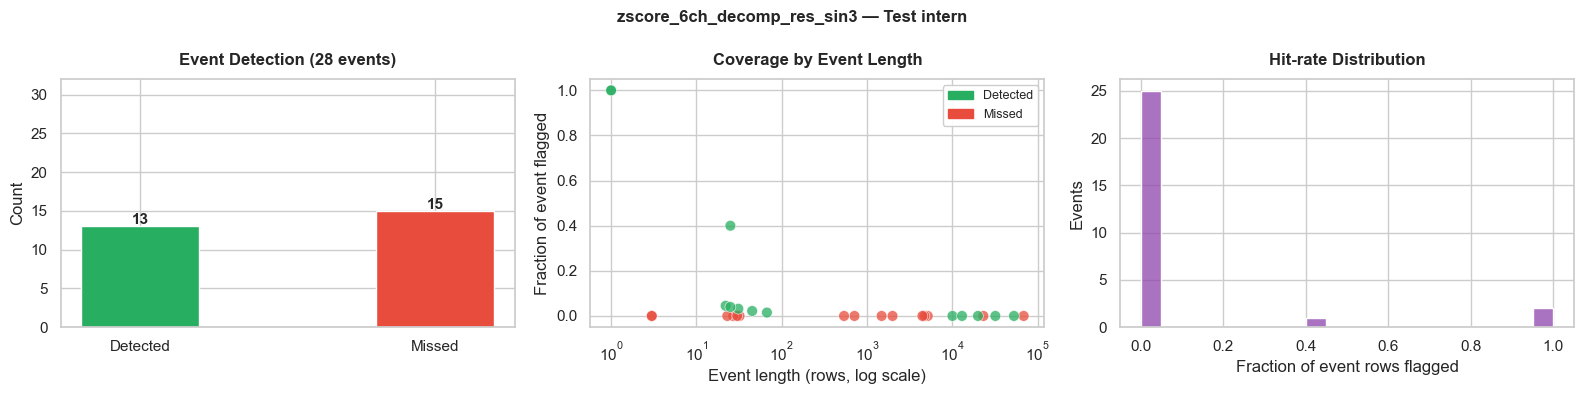

Missed events:
  start     end  length
      0   23028   23029
 423427  424906    1480
 666547  671682    5136
 903560  908251    4692
1118513 1118544      32
1119149 1119175      27
1120665 1120687      23
1121303 1121332      30
1486515 1487225     711
1678802 1747142   68341
1871764 1873749    1986
2097753 2098289     537
2130594 2130596       3
2130609 2130611       3
2130732 2135180    4449


In [87]:
def plot_event_analysis(df, title):
    if len(df) == 0:
        print(f'{title}: no true events.'); return
    n_det  = int(df['detected'].sum())
    n_miss = len(df) - n_det
    n_ev   = len(df)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    counts = pd.Series({'Detected': n_det, 'Missed': n_miss})
    bars = ax.bar(counts.index, counts.values, color=['#27ae60', ANOMALY_COLOR],
                  edgecolor='white', width=0.4)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                str(v), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Event Detection ({n_ev} events)', fontweight='bold')
    ax.set_ylabel('Count'); ax.set_ylim(0, n_ev + 4)

    ax2 = axes[1]
    colors_pt = [('#27ae60' if d else ANOMALY_COLOR) for d in df['detected']]
    ax2.scatter(df['length'], df['hit_rate'], c=colors_pt, s=60, alpha=0.75,
                edgecolors='white', lw=0.5)
    ax2.set_xscale('log')
    ax2.set_xlabel('Event length (rows, log scale)')
    ax2.set_ylabel('Fraction of event flagged')
    ax2.set_title('Coverage by Event Length', fontweight='bold')
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(handles=[mpatches.Patch(color='#27ae60', label='Detected'),
                         mpatches.Patch(color=ANOMALY_COLOR, label='Missed')], fontsize=9)

    ax3 = axes[2]
    sns.histplot(df['hit_rate'], bins=20, ax=ax3, color='#8e44ad', edgecolor='white')
    ax3.set_xlabel('Fraction of event rows flagged')
    ax3.set_ylabel('Events')
    ax3.set_title('Hit-rate Distribution', fontweight='bold')

    fig.suptitle(title, fontsize=12, fontweight='bold')
    fig.tight_layout(); plt.show()

    if n_miss:
        print('Missed events:')
        print(df[~df['detected']][['start','end','length']].to_string(index=False))

plot_event_analysis(df_val,  f'{MODEL_NAME} — Val')
plot_event_analysis(df_test, f'{MODEL_NAME} — Test intern')

## Save model & sbmission 

In [88]:
# from datetime import datetime
# from sentinel.ml_logic.data import PROCESSED_DIR
#
# stamp   = datetime.now().strftime('%Y%m%d_%H%M%S')
# out_dir = PROCESSED_DIR / 'scores'
# out_dir.mkdir(parents=True, exist_ok=True)
#
# np.save(out_dir / f'scores_val_{MODEL_NAME}_{stamp}.npy',      scores_val)
# np.save(out_dir / f'scores_test_int_{MODEL_NAME}_{stamp}.npy', scores_test_int)
#
# with open(out_dir / f'config_{MODEL_NAME}_{stamp}.json', 'w') as f:
#     json.dump({
#         'model_name'       : MODEL_NAME,
#         'base_channels'    : BASE_CHANNELS,
#         'subchannel_parts' : SUBCHANNEL_PARTS,
#         'big_window'       : BIG_WINDOW_DECOMP,
#         'window_by_part'   : WINDOW_BY_PART,
#         'freq_map'         : freq_map,
#         'best_p'           : best_p,
#         'threshold'        : float(THRESHOLD),
#         'val_esa_f05'      : float(m_val['esa_f05']),
#         'test_esa_f05'     : float(m_test['esa_f05']),
#         'tune_metric'      : 'corrected_event_f05',
#     }, f, indent=2)
# print(f'saved scores + config to {out_dir}  (stamp {stamp})')

### Kaggle submission 

Applies decomposition + multi-window z-score to `test.parquet`, same `best_p` + threshold, writes schema-validated parquet via `make_submission`.

In [89]:
# import sys
# sys.path.insert(0, '..')
# from datetime import datetime
# from kaggle.submission import make_submission, default_submission_path, submission_summary

# # test has already been decomposed in §4 — compute multi-window z-score over the
# # active CHANNELS, aggregate via top-p, threshold.
# print(f'Multi-window Z-score on Kaggle test ({len(test):,} rows × {len(CHANNELS)} features) …')
# z_test_kaggle      = rolling_zscore_multiwindow(test[CHANNELS], CHANNELS, WINDOW_BY_PART)
# scores_test_kaggle = top_p_mean(z_test_kaggle.values, p=best_p)
# y_pred_kaggle      = (scores_test_kaggle > THRESHOLD).astype(np.uint8)

# print(f'Kaggle score range : [{scores_test_kaggle.min():.3f}, {scores_test_kaggle.max():.3f}]')
# print(f'Kaggle flag rate   : {y_pred_kaggle.mean():.4%}  ({int(y_pred_kaggle.sum()):,} / {len(y_pred_kaggle):,})')

# stamp    = datetime.now().strftime('%Y%m%d_%H%M%S')
# out_path = default_submission_path(f'{SUBMISSION_STEM}_{stamp}')
# test_ids = test.index.values.astype(np.int64)

# submission = make_submission(
#     predictions     = y_pred_kaggle,
#     test_ids        = test_ids,
#     out_path        = out_path,
#     validate_schema = True,
# )
# print(f'Wrote: {out_path}')
# print(submission_summary(submission))